# Variational auto Encoders

In [2]:
import tensorflow as tf
import os
import random
import numpy as np

2025-10-20 19:32:35.857267: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-20 19:32:35.890049: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-20 19:32:35.890073: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-20 19:32:35.890078: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-20 19:32:35.895949: I tensorflow/core/platform/cpu_feature_g

In [ ]:
SEED = 1234567
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
from tensorflow.keras.datasets import fashion_mnist

(x_train,y_train),(x_test, y_test) = fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

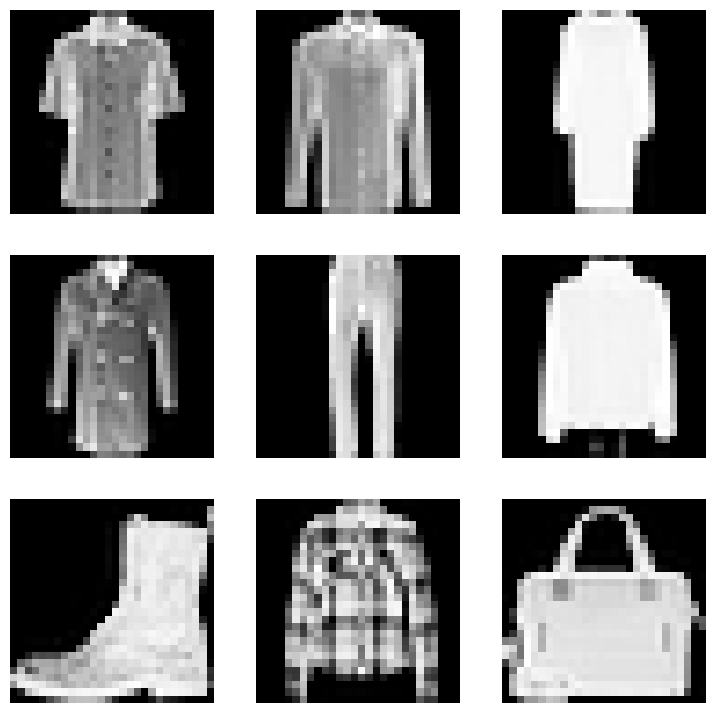

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize = (9, 9))

rnd_samples = np.random.choice(60000, 9)

for i in range(9): 
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[rnd_samples[i]], cmap='Grays_r')
    plt.axis('off')

plt.show()

In [ ]:
dataset = np.concatenate([x_train, x_test], axis=0)

dataset = np.expand_dims(dataset, -1).astype('float32') / 255

## Custom Ssmpling Layer

In [ ]:
from tensorflow import keras
from keras import layers

class SampleLayer(layers.Layer):
    '''Reparameterization trick z = mu + sigma * epslion'''
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = keras.backend.random_normal(shape=(batch, dim))

        return z_mean * tf.exp(0.5 * z_log_var)* epsilon

In [19]:
def build_encoder(latent_dim, encoder_inputs):
    li = keras.models.Sequential(
        [
            layers.Conv2D(128, 3, activation="relu", strides=2, padding="same"),
            layers.Conv2D(64, 3, activation="relu", strides=2, padding="same"),
            layers.Flatten(),
            layers.Dense(32, acitvation="relu"),
        ]
    )
    x = li(encoder_inputs)
    z_mean = layers.Dense(latent_dim, name="z_name")(x)
    z_log_var = layers.Dense(latent_dim, name="z_logvar")(x)
    z = SampleLayer()([z_mean, z_log_var])

    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")


encoder_inputs = keras.Input(shape=(28, 28, 1))
encoder = build_encoder(2, encoder_inputs)
encoder.summary()

TypeError: ('Keyword argument not understood:', 'acitvation')